# Import Libraries & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from joblib import dump,load

In [34]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [36]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Data Preprocessing

## Filling missing values

In [39]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0


(array([1.5304e+04, 4.1460e+03, 6.8200e+02, 1.7700e+02, 7.0000e+01,
        2.3000e+01, 1.8000e+01, 8.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([1.0000e+00, 6.4540e+02, 1.2898e+03, 1.9342e+03, 2.5786e+03,
        3.2230e+03, 3.8674e+03, 4.5118e+03, 5.1562e+03, 5.8006e+03,
        6.4450e+03]),
 <BarContainer object of 10 artists>)

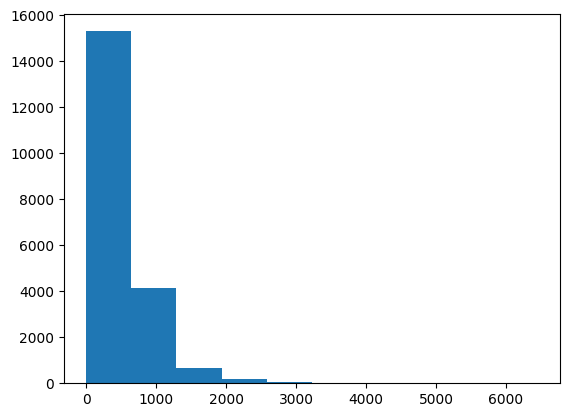

In [40]:
plt.hist(df['total_bedrooms'])

In [41]:
col= ['total_bedrooms']
imputer = KNNImputer(missing_values = np.nan,n_neighbors=5 )
df[col] = imputer.fit_transform(df[col])

(array([1.5511e+04, 4.1460e+03, 6.8200e+02, 1.7700e+02, 7.0000e+01,
        2.3000e+01, 1.8000e+01, 8.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([1.0000e+00, 6.4540e+02, 1.2898e+03, 1.9342e+03, 2.5786e+03,
        3.2230e+03, 3.8674e+03, 4.5118e+03, 5.1562e+03, 5.8006e+03,
        6.4450e+03]),
 <BarContainer object of 10 artists>)

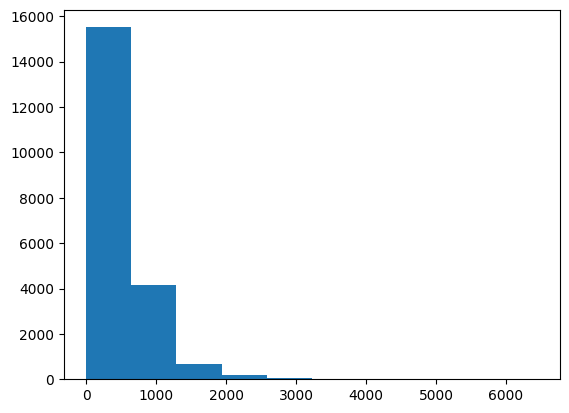

In [42]:
plt.hist(df['total_bedrooms'])


In [43]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


### outliers

In [45]:
cols_to_cap = ['median_house_value','median_income','housing_median_age']

In [46]:
def get_bounds(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

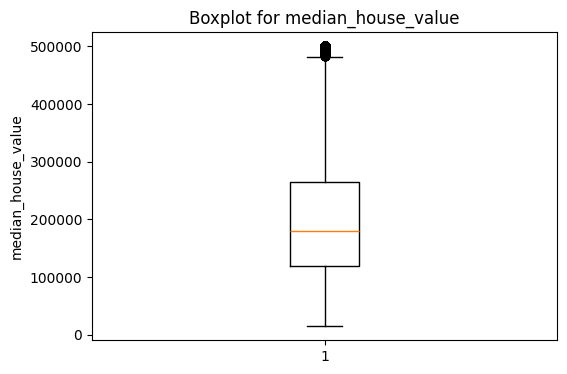

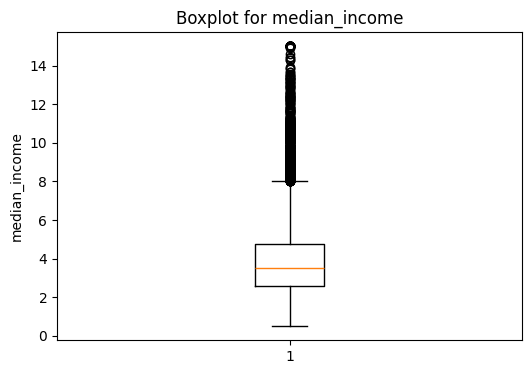

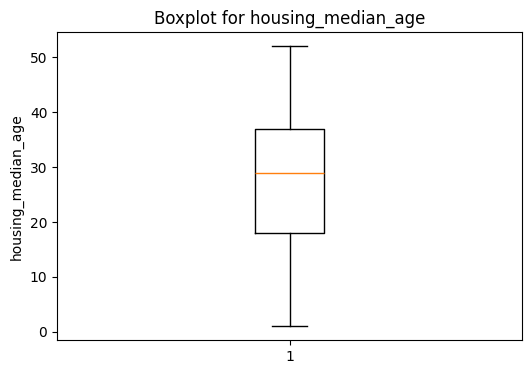

In [47]:
for col in cols_to_cap:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot for {col}')
    plt.ylabel(col)
    plt.show()


In [48]:
for col in cols_to_cap:
    lower, upper = get_bounds(df[col])
    df[col] = df[col].clip(lower=lower, upper=upper)


### split X,y /train,test

In [50]:
X = df.drop('median_house_value', axis=1).values
y = df['median_house_value'].values
X

array([[-1.222300e+02,  3.788000e+01,  4.100000e+01, ...,  3.220000e+02,
         1.260000e+02,  8.013025e+00],
       [-1.222200e+02,  3.786000e+01,  2.100000e+01, ...,  2.401000e+03,
         1.138000e+03,  8.013025e+00],
       [-1.222400e+02,  3.785000e+01,  5.200000e+01, ...,  4.960000e+02,
         1.770000e+02,  7.257400e+00],
       ...,
       [-1.212200e+02,  3.943000e+01,  1.700000e+01, ...,  1.007000e+03,
         4.330000e+02,  1.700000e+00],
       [-1.213200e+02,  3.943000e+01,  1.800000e+01, ...,  7.410000e+02,
         3.490000e+02,  1.867200e+00],
       [-1.212400e+02,  3.937000e+01,  1.600000e+01, ...,  1.387000e+03,
         5.300000e+02,  2.388600e+00]])

In [51]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.013025,452600.0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.013025,358500.0
2,-122.24,37.85,52,1467,190.0,496,177,7.257400,352100.0
3,-122.25,37.85,52,1274,235.0,558,219,5.643100,341300.0
4,-122.25,37.85,52,1627,280.0,565,259,3.846200,342200.0


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

### scaling data

In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Models

In [56]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# Evaluation with cross-validation and grid search

In [58]:
results_cv = []
trained_models = {}

for name, model in models.items():
    # cross validation on 5 layers
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,  # split numbers
        scoring={
            'r2': 'r2',
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error'
        },
        return_train_score=False
    )

    # average of scores
    avg_r2 = np.mean(scores['test_r2'])
    avg_rmse = np.mean(-scores['test_rmse'])
    avg_mae = np.mean(-scores['test_mae'])

    results_cv.append({
        'Model': name,
        'CV_Avg_R2': avg_r2,
        'CV_Avg_RMSE': avg_rmse,
        'CV_Avg_MAE': avg_mae
    })


In [59]:
# sort based on best models
results_cv_df = pd.DataFrame(results_cv)
print(results_cv_df.sort_values('CV_Avg_R2', ascending=False).round(4))

               Model  CV_Avg_R2  CV_Avg_RMSE  CV_Avg_MAE
4      Random Forest     0.8161   48568.9525  31983.4955
5                KNN     0.7010   61939.5393  42911.4245
1   Ridge Regression     0.6410   67856.3809  50490.8002
2   Lasso Regression     0.6410   67856.9321  50490.9998
0  Linear Regression     0.6410   67856.9385  50490.9831
3      Decision Tree     0.6356   68360.7387  43695.4591


/tmp/ipykernel_2252/477071433.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2252/477071433.py:12: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'darkred'}` instead.

  ax = sns.barplot(
/tmp/ipykernel_2252/477071433.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  ax = sns.barplot(
/tmp/ipykernel_2252/477071433.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)


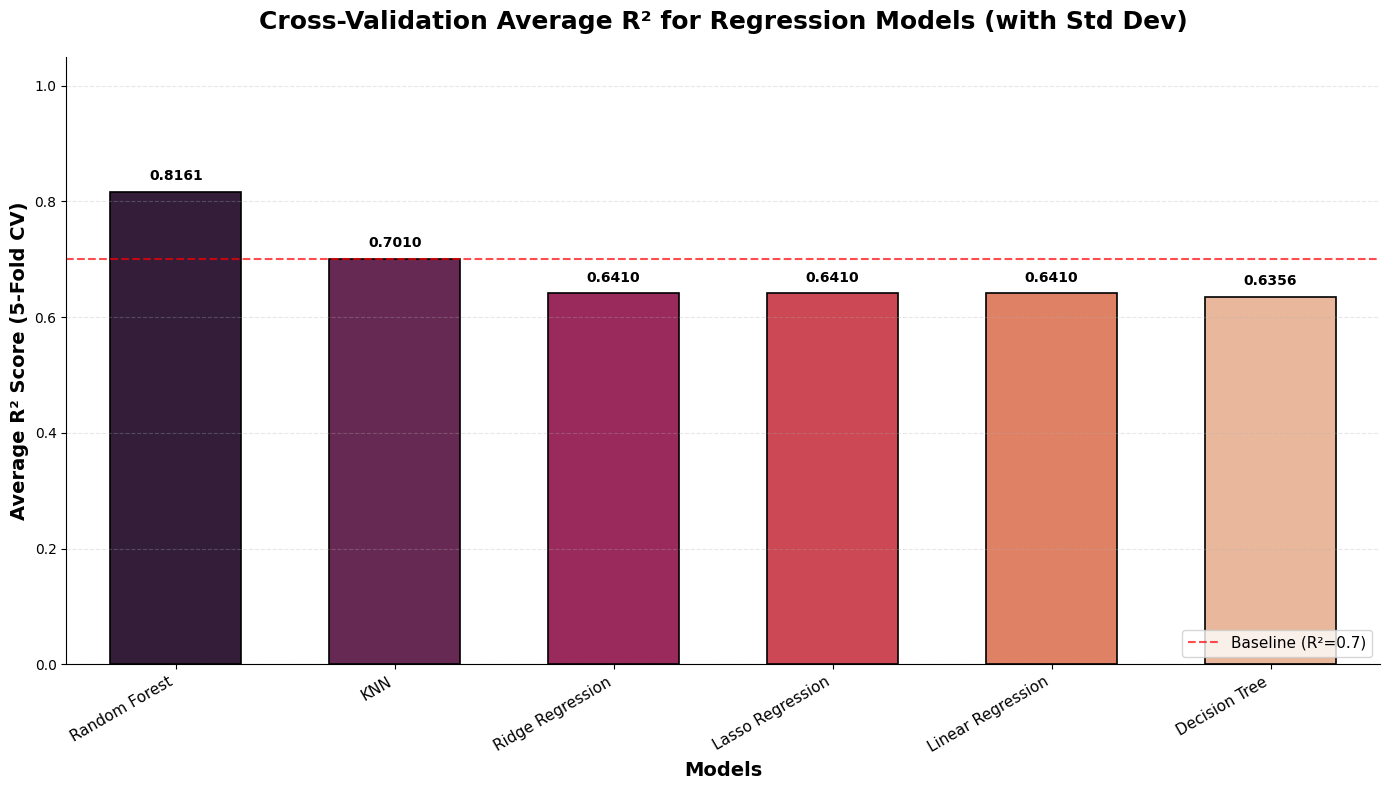

In [60]:
# results_cv_df
# Model, CV_Avg_R2, CV_R2_std, CV_Avg_RMSE

# sort by r2
df_plot_cv = results_cv_df.sort_values('CV_Avg_R2', ascending=False).reset_index(drop=True)

# palette
plt.figure(figsize=(14, 8))
palette = sns.color_palette("rocket", n_colors=len(df_plot_cv))

# bars
ax = sns.barplot(
    data=df_plot_cv,
    x='Model',
    y='CV_Avg_R2',
    palette=palette,
    edgecolor='black',
    linewidth=1.2,
    width=0.6,
    yerr=df_plot_cv['CV_R2_std'] if 'CV_R2_std' in df_plot_cv else None,
    capsize=5,
    errcolor='darkred',
    errwidth=2
)

# show mean
for i, row in df_plot_cv.iterrows():
    ax.text(
        i,
        row['CV_Avg_R2'] + 0.015,
        f"{row['CV_Avg_R2']:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# labels
ax.set_title('Cross-Validation Average R² for Regression Models (with Std Dev)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Average R² Score (5-Fold CV)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# model names rotation
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)

# base line
ax.axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Baseline (R²=0.7)')
ax.legend(loc='lower right', fontsize=11)

# adding grid
sns.despine(top=True, right=True, left=False, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# grid search for the  best models

### Random Forest

In [81]:
# Random Forest
print("Grid Search for Random Forest")
param_grid_rf = {
    'n_estimators': [50, 80,150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

Grid Search for Random Forest


In [82]:
rf = RandomForestRegressor(random_state=42)
grid_rf = RandomizedSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [50, 80, 150]},
                   scoring='r2', verbose=1)

In [83]:
print("Best params for RF:", grid_rf.best_params_)
print("Best CV R² for RF:", grid_rf.best_score_)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print(f"Test R² for optimized RF: {r2_score(y_test, y_pred_rf):.4f}")

Best params for RF: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV R² for RF: 0.8180826497366407
Test R² for optimized RF: 0.8140


In [90]:
import joblib

#save
joblib.dump(best_rf, "best_rf_model.pkl")

['best_rf_model.pkl']

### knn

In [77]:
# KNN
print("Grid Search for KNN...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

Grid Search for KNN...


In [78]:
knn = KNeighborsRegressor()
grid_knn = RandomizedSearchCV(knn, param_grid_knn, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
                   param_distributions={'n_neighbors': [3, 5, 7, 9, 11],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   scoring='r2', verbose=1)

In [79]:
print("Best params for KNN:", grid_knn.best_params_)
print("Best CV R² for KNN:", grid_knn.best_score_)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
print(f"Test R² for optimized KNN: {r2_score(y_test, y_pred_knn):.4f}\n")

Best params for KNN: {'weights': 'distance', 'p': 1, 'n_neighbors': 7}
Best CV R² for KNN: 0.7281185432017073
Test R² for optimized KNN: 0.7207



In [91]:
#save
joblib.dump(best_knn, "best_knn_model.pkl")


['best_knn_model.pkl']

### Summary

In [84]:
print("\n" + "="*60)
print("FINAL COMPARISON AFTER GRID SEARCH:")
print(f"Optimized Random Forest Test R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Optimized KNN Test R²:          {r2_score(y_test, y_pred_knn):.4f}")


FINAL COMPARISON AFTER GRID SEARCH:
Optimized Random Forest Test R²: 0.8140
Optimized KNN Test R²:          0.7207
